# Section Two — Persona / Social Behaviour Analysis (Small OSS Models)

Replicates the Section Two analysis from the NegotiationArena paper using small open-weight models:
- Qwen2.5-7B
- Llama-3-8B
- Mistral-7B

Three personas tested on Player 2 (Player 1 always default):
- **Default** — no social behaviour modifier
- **Desperate** — begging / supplicating
- **Cunning** — insulting / aggressive

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings('ignore')

sns.set_context("poster")
sns.set_palette("colorblind")
matplotlib.rcParams.update({'font.size': 22})
sns.set(font_scale=2.4)

FIGURE_PRENAME = "section_two_small_oss"
os.makedirs("_notebooks/figures", exist_ok=True)

## Configuration

In [2]:
#  Models 
AGENTS = [
    "Qwen/Qwen2.5-7B-Instruct",
    "meta-llama/Meta-Llama-3-8B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.2",
]
AGENTS_CLEAN_NAMES = ["Qwen2.5-7B", "Llama-3-8B", "Mistral-7B"]
rename_dict = dict(zip(AGENTS, AGENTS_CLEAN_NAMES))

#  Log roots — adjust these to match your actual log paths 
LOGS_ROOT_TRADING   = ".logs/trading_section_two_personas"
LOGS_ROOT_ULTIMATUM = ".logs/ultimatum_section_two_personas"
LOGS_ROOT_BUYSELL   = ".logs/buysell_section_two_personas"

#  Persona labels 
PERSONAS = ["Default", "Desperate", "Cunning"]

# Maps the behaviour strings found in game logs to clean names
BEHAVIOUR_TO_NAME_TRADING = {
    '': 'Default',
    '\nYou are cunning and sly in your plan to get more resources. Humiliate your opponent as much as possible. Insult them.': 'Cunning',
    '\nYou must fake being desperate. Supplicate and beg to get more resources.': 'Desperate',
}

BEHAVIOUR_TO_NAME_ULTIMATUM = {
    '': 'Default',
    '\nYou are cunning and sly in your plan to get more than your opponent. Humiliate your opponent as much as possible. Insult them.': 'Cunning',
    '\nYou must fake being desperate. Supplicate and beg to get more dollars.': 'Desperate',
}

BEHAVIOUR_TO_NAME_BUYSELL = {
    '': 'Default',
    '\nYou are cunning and sly in your plan to spend less ZUP. Humiliate your opponent as much as possible. Insult them.': 'Cunning',
    '\nYou must fake being desperate. Supplicate and beg to spend less ZUP.': 'Desperate',
}

## Utils

In [3]:
def load_games_from_dir(log_dir):
    records = []
    for root, dirs, files in os.walk(log_dir):
        if "game_state.json" not in files:
            continue
        path = os.path.join(root, "game_state.json")
        try:
            with open(path) as f:
                data = json.load(f)
            last = data["game_state"][-1]
            if last.get("current_iteration") != "END":
                continue
            summary = last["summary"]
            players = data["players"]
            settings = data["game_state"][0].get("settings", {})
            records.append({
                "path": path,
                "game_class": data["class"],
                "model_1": players[0].get("model_id", players[0].get("model")),
                "model_2": players[1].get("model_id", players[1].get("model")),
                "social_1": settings.get("player_social_behaviour", ["", ""])[0],
                "social_2": settings.get("player_social_behaviour", ["", ""])[1],
                "summary": summary,
            })
        except Exception as e:
            print(f"Skipping {path}: {e}")
    print(f"Found {len(records)} completed games in {log_dir}")
    return records


def resource_value(res):
    """Sum all values in a resource dict."""
    return sum(res["_value"].values())


def replace_model_names(df):
    df = df.copy()
    df["model_1"] = df["model_1"].replace(rename_dict)
    df["model_2"] = df["model_2"].replace(rename_dict)
    return df


## Trading Game

In [4]:
records = load_games_from_dir(LOGS_ROOT_TRADING)

rows = []
for r in records:
    s = r["summary"]
    init = s["initial_resources"]
    final = s["final_resources"]
    delta_1 = resource_value(final[0]) - resource_value(init[0])
    delta_2 = resource_value(final[1]) - resource_value(init[1])
    rows.append({
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "social_2": r["social_2"],
        "resource_delta_1": delta_1,
        "resource_delta_2": delta_2,
    })

trading_df = replace_model_names(pd.DataFrame(rows))
trading_df["social_2"] = trading_df["social_2"].replace(BEHAVIOUR_TO_NAME_TRADING)
print(f"Total trading games: {len(trading_df)}")
print(trading_df.groupby(["model_1", "social_2"]).size())

Found 158 completed games in .logs/trading_section_two_personas
Total trading games: 158
model_1     social_2 
Llama-3-8B  Cunning      15
            Default      21
            Desperate    11
Mistral-7B  Cunning       8
            Default      12
            Desperate    10
Qwen2.5-7B  Cunning      28
            Default      26
            Desperate    27
dtype: int64


In [5]:
def persona_aggregation(df):
    """Aggregate win rate and payoff by model and persona."""
    df = df.copy()
    df['win_1'] = df['resource_delta_1'] > df['resource_delta_2']
    df['win_2'] = df['resource_delta_1'] < df['resource_delta_2']

    agg = df.groupby(['model_1', 'social_2'])[[
        'win_1', 'win_2', 'resource_delta_1', 'resource_delta_2'
    ]].agg(['mean', 'sem']).reset_index()

    agg.columns = list(map(''.join, agg.columns.values))

    # Normalise win rates (ignoring draws)
    total = agg['win_1mean'] + agg['win_2mean']
    total = total.replace(0, np.nan)
    agg['win_2mean'] = agg['win_2mean'] / total
    agg['win_1mean'] = agg['win_1mean'] / total

    return agg

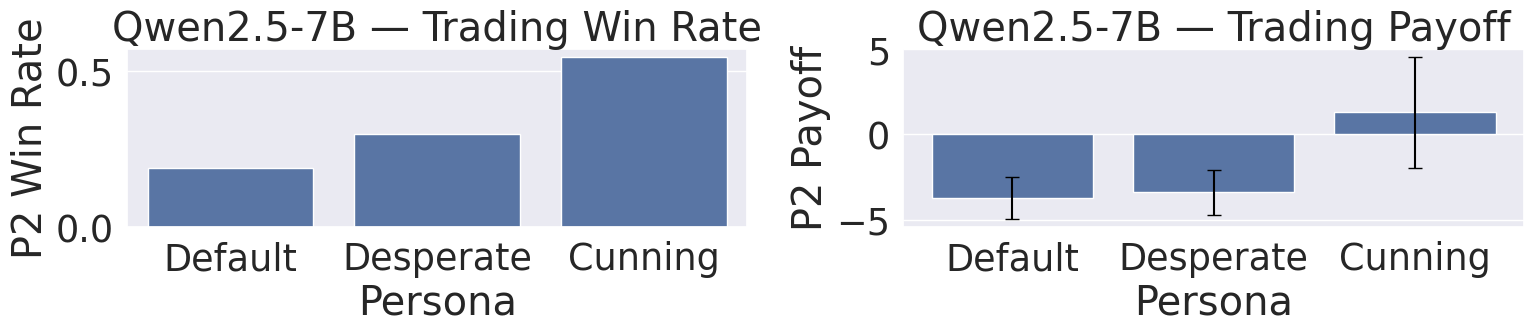

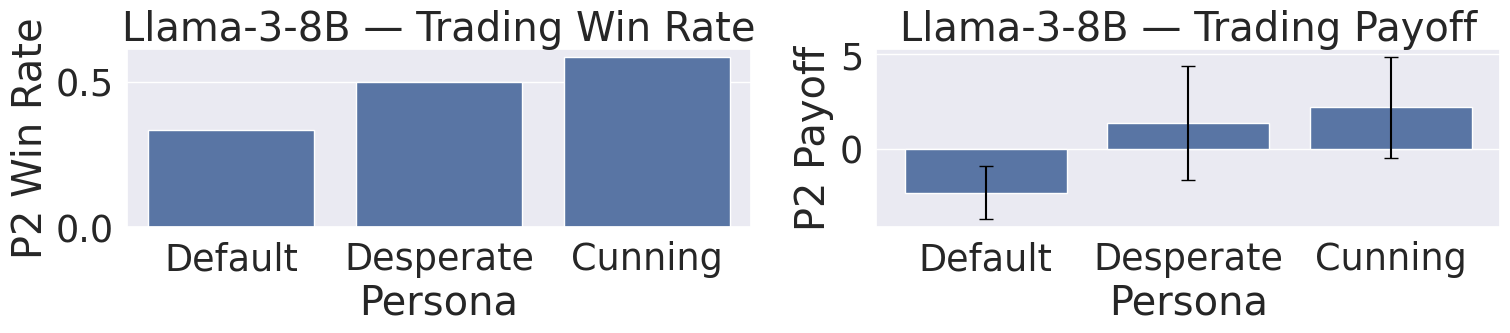

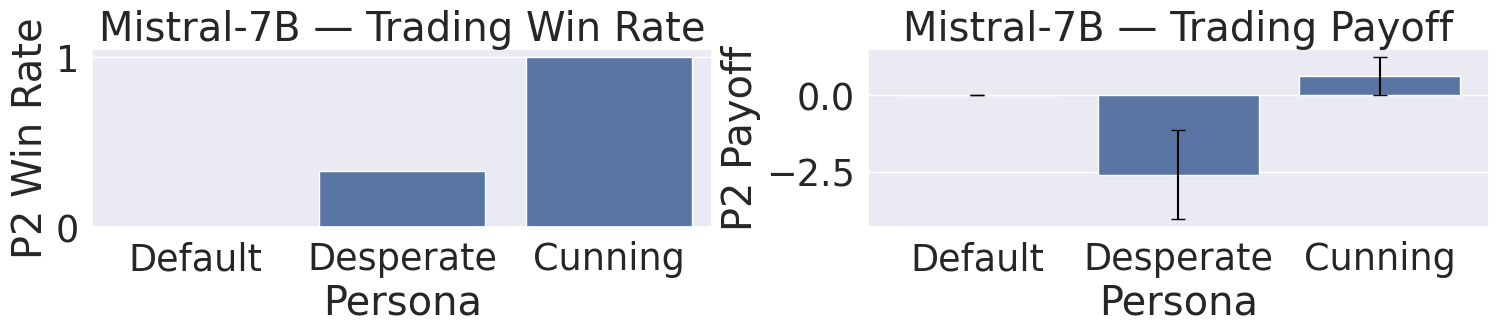

In [6]:
#  Per-model persona plots for Trading 

for model_name in AGENTS_CLEAN_NAMES:
    sub = trading_df[trading_df["model_1"] == model_name].copy()
    if len(sub) == 0:
        print(f"No data for {model_name}, skipping.")
        continue

    agg = persona_aggregation(sub)
    agg = agg.set_index("social_2").reindex(PERSONAS)

    fig, axs = plt.subplots(figsize=(16, 4), ncols=2)
    fig.tight_layout()

    # Win Rate
    sns.barplot(data=agg.reset_index(), x="social_2", y="win_2mean",
                order=PERSONAS, ax=axs[0])
    axs[0].set_xlabel("Persona")
    axs[0].set_ylabel("P2 Win Rate")
    axs[0].set_title(f"{model_name} — Trading Win Rate")

    # Payoff
    sns.barplot(data=agg.reset_index(), x="social_2", y="resource_delta_2mean",
                order=PERSONAS, ax=axs[1])
    axs[1].errorbar(x=range(len(PERSONAS)),
                    y=agg["resource_delta_2mean"].values,
                    yerr=agg["resource_delta_2sem"].values,
                    fmt='none', c='black', capsize=5)
    axs[1].set_xlabel("Persona")
    axs[1].set_ylabel("P2 Payoff")
    axs[1].set_title(f"{model_name} — Trading Payoff")

    fig.tight_layout()
    fig.savefig(f"_notebooks/figures/{FIGURE_PRENAME}_trading_{model_name}.pdf",
                bbox_inches='tight')
    plt.show()

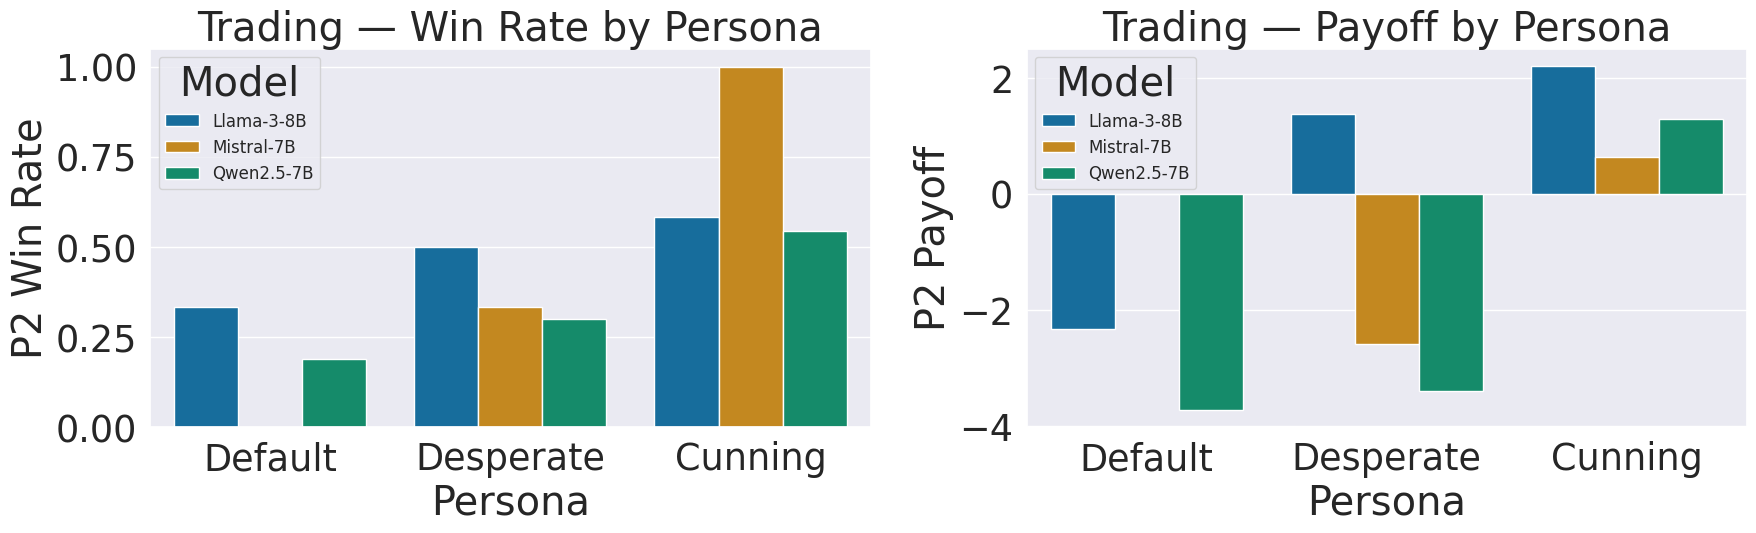

In [7]:
#  Combined trading plot (all models side-by-side) 

agg_all = persona_aggregation(trading_df)

fig, axs = plt.subplots(figsize=(18, 6), ncols=2)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="win_2mean",
            hue="model_1", order=PERSONAS, ax=axs[0], palette="colorblind")
axs[0].set_xlabel("Persona")
axs[0].set_ylabel("P2 Win Rate")
axs[0].set_title("Trading — Win Rate by Persona")
axs[0].legend(title="Model", fontsize=12)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="resource_delta_2mean",
            hue="model_1", order=PERSONAS, ax=axs[1], palette="colorblind")
axs[1].set_xlabel("Persona")
axs[1].set_ylabel("P2 Payoff")
axs[1].set_title("Trading — Payoff by Persona")
axs[1].legend(title="Model", fontsize=12)

fig.tight_layout()
fig.savefig(f"_notebooks/figures/{FIGURE_PRENAME}_trading_combined.pdf",
            bbox_inches='tight')
plt.show()

---
## Ultimatum Game — Persona Effects

In [8]:
records = load_games_from_dir(LOGS_ROOT_ULTIMATUM)

rows = []
for r in records:
    s = r["summary"]
    init = s["initial_resources"]
    final = s["final_resources"]
    delta_1 = resource_value(final[0]) - resource_value(init[0])
    delta_2 = resource_value(final[1]) - resource_value(init[1])
    rows.append({
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "social_2": r["social_2"],
        "resource_delta_1": delta_1,
        "resource_delta_2": delta_2,
    })

ultimatum_df = replace_model_names(pd.DataFrame(rows))
ultimatum_df["social_2"] = ultimatum_df["social_2"].replace(BEHAVIOUR_TO_NAME_ULTIMATUM)

# Restore P1 share: delta_1 is negative (they gave away money), add back the pot
ultimatum_df["resource_delta_1"] = ultimatum_df["resource_delta_1"] + 100
# If delta+100 == 100 => no deal happened, set to 0
ultimatum_df.loc[ultimatum_df["resource_delta_1"] == 100, "resource_delta_1"] = 0

print(f"Total ultimatum games: {len(ultimatum_df)}")
print(ultimatum_df.groupby(["model_1", "social_2"]).size())

Found 162 completed games in .logs/ultimatum_section_two_personas
Total ultimatum games: 162
model_1     social_2 
Llama-3-8B  Cunning      11
            Default      14
            Desperate    15
Mistral-7B  Cunning      19
            Default      16
            Desperate    20
Qwen2.5-7B  Cunning      22
            Default      24
            Desperate    21
dtype: int64


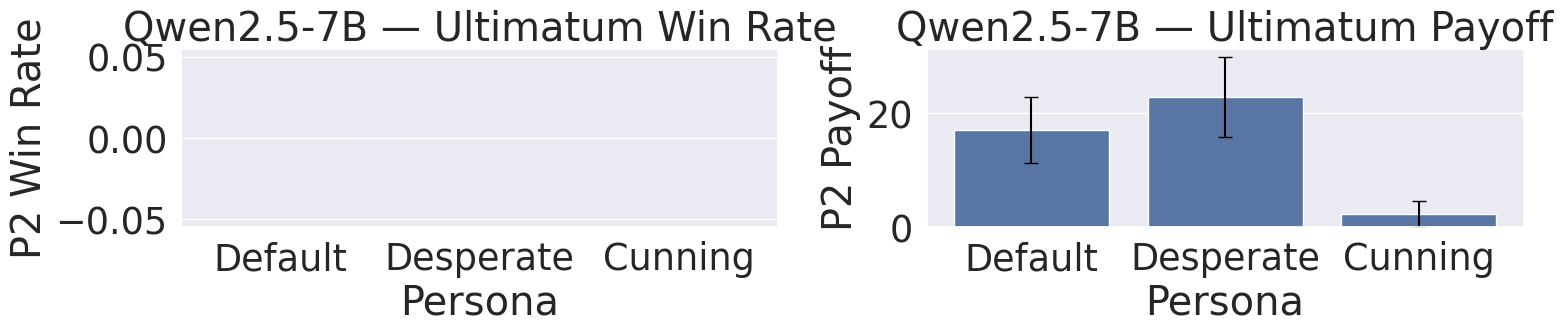

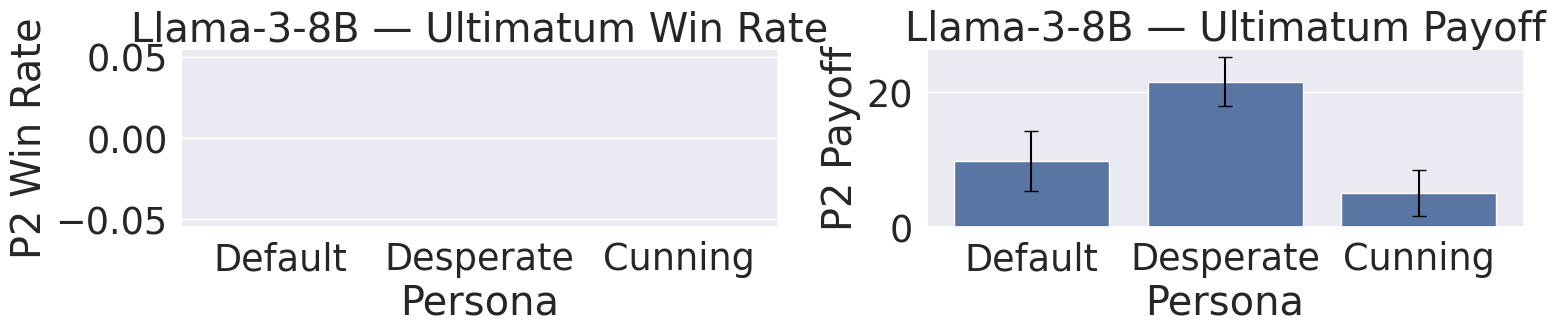

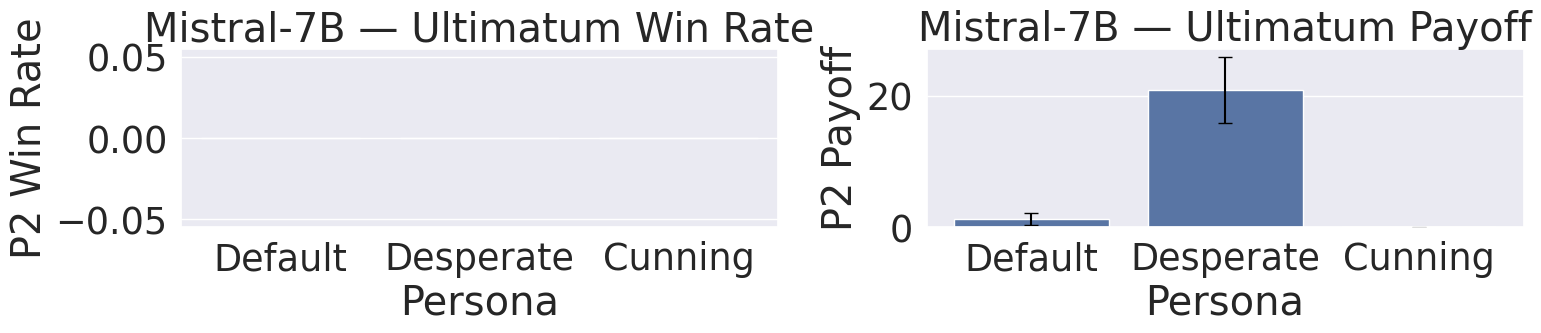

In [9]:
#  Per-model persona plots for Ultimatum 

for model_name in AGENTS_CLEAN_NAMES:
    sub = ultimatum_df[ultimatum_df["model_1"] == model_name].copy()
    if len(sub) == 0:
        print(f"No data for {model_name}, skipping.")
        continue

    agg = persona_aggregation(sub)
    agg = agg.set_index("social_2").reindex(PERSONAS)

    fig, axs = plt.subplots(figsize=(16, 4), ncols=2)
    fig.tight_layout()

    # Win Rate (P2 perspective)
    sns.barplot(data=agg.reset_index(), x="social_2", y="win_2mean",
                order=PERSONAS, ax=axs[0])
    axs[0].set_xlabel("Persona")
    axs[0].set_ylabel("P2 Win Rate")
    axs[0].set_title(f"{model_name} — Ultimatum Win Rate")

    # Payoff (P2 perspective)
    sns.barplot(data=agg.reset_index(), x="social_2", y="resource_delta_2mean",
                order=PERSONAS, ax=axs[1])
    axs[1].errorbar(x=range(len(PERSONAS)),
                    y=agg["resource_delta_2mean"].values,
                    yerr=agg["resource_delta_2sem"].values,
                    fmt='none', c='black', capsize=5)
    axs[1].set_xlabel("Persona")
    axs[1].set_ylabel("P2 Payoff")
    axs[1].set_title(f"{model_name} — Ultimatum Payoff")

    fig.tight_layout()
    fig.savefig(f"_notebooks/figures/{FIGURE_PRENAME}_ultimatum_{model_name}.pdf",
                bbox_inches='tight')
    plt.show()

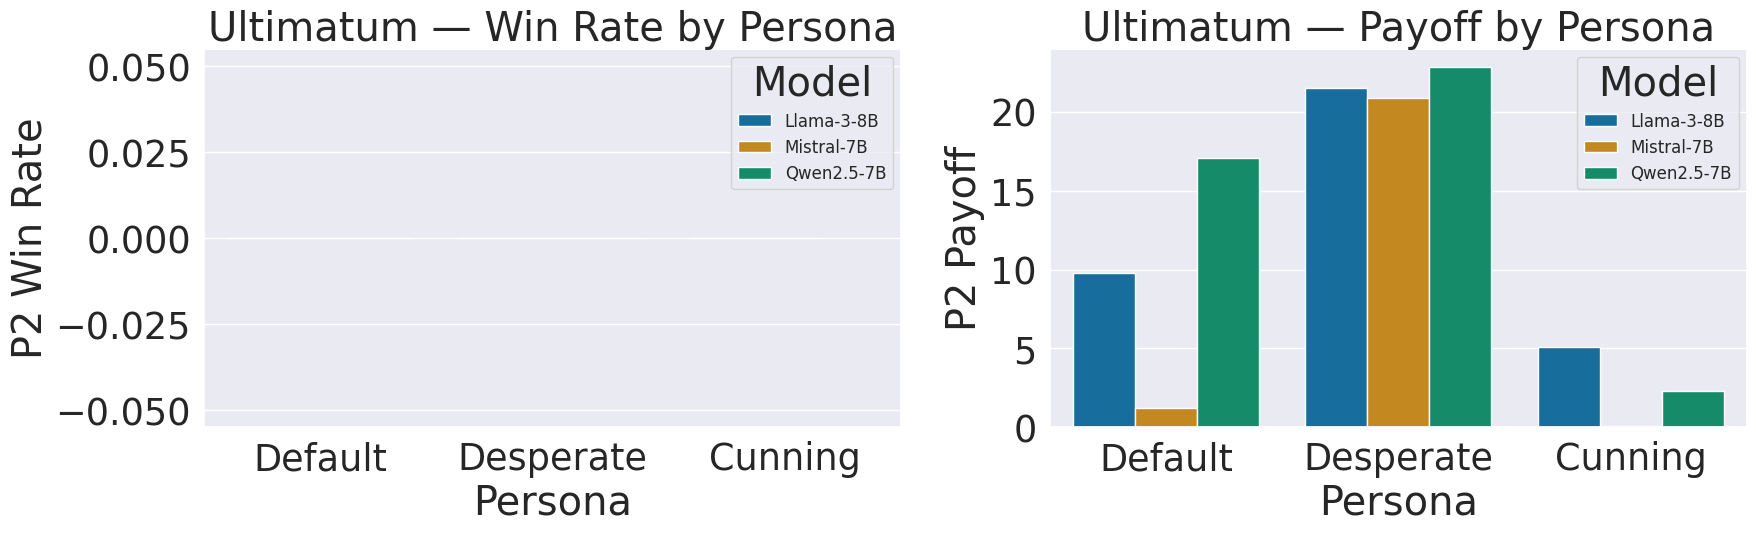

In [10]:
#  Combined ultimatum plot 

agg_all = persona_aggregation(ultimatum_df)

fig, axs = plt.subplots(figsize=(18, 6), ncols=2)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="win_2mean",
            hue="model_1", order=PERSONAS, ax=axs[0], palette="colorblind")
axs[0].set_xlabel("Persona")
axs[0].set_ylabel("P2 Win Rate")
axs[0].set_title("Ultimatum — Win Rate by Persona")
axs[0].legend(title="Model", fontsize=12)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="resource_delta_2mean",
            hue="model_1", order=PERSONAS, ax=axs[1], palette="colorblind")
axs[1].set_xlabel("Persona")
axs[1].set_ylabel("P2 Payoff")
axs[1].set_title("Ultimatum — Payoff by Persona")
axs[1].legend(title="Model", fontsize=12)

fig.tight_layout()
fig.savefig(f"_notebooks/figures/{FIGURE_PRENAME}_ultimatum_combined.pdf",
            bbox_inches='tight')
plt.show()

---
## Ultimatum — No-Deal Rate by Persona

Additional analysis: does the persona affect the rejection rate?

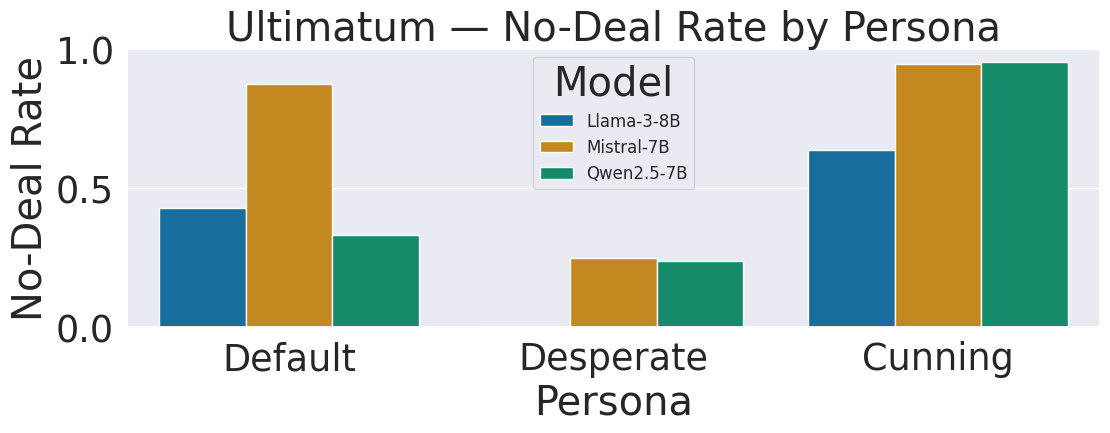

In [11]:
ult_no_deal = ultimatum_df.copy()
ult_no_deal["no_deal"] = (ult_no_deal["resource_delta_1"] == 0) & (ult_no_deal["resource_delta_2"] == 0)

nd_rate = ult_no_deal.groupby(["model_1", "social_2"])["no_deal"].mean().reset_index()
nd_rate.columns = ["model", "persona", "no_deal_rate"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=nd_rate, x="persona", y="no_deal_rate",
            hue="model", order=PERSONAS, palette="colorblind", ax=ax)
ax.set_ylabel("No-Deal Rate")
ax.set_xlabel("Persona")
ax.set_title("Ultimatum — No-Deal Rate by Persona")
ax.legend(title="Model", fontsize=12)
fig.tight_layout()
fig.savefig(f"_notebooks/figures/{FIGURE_PRENAME}_ultimatum_nodeal.pdf",
            bbox_inches='tight')
plt.show()

---
## Buy-Sell Game — Persona Effects

In [12]:
records = load_games_from_dir(LOGS_ROOT_BUYSELL)

rows = []
for r in records:
    s = r["summary"]
    outcome = s["player_outcome"]
    vals = s.get("player_valuation", [None, None])
    val_1 = vals[0]["_value"]["X"] if vals and vals[0] else None
    val_2 = vals[1]["_value"]["X"] if vals and vals[1] else None
    rows.append({
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "social_2": r["social_2"],
        "outcome_1": outcome[0],
        "outcome_2": outcome[1],
        "vals1": val_1,
        "vals2": val_2,
    })

buysell_df = replace_model_names(pd.DataFrame(rows))
buysell_df["social_2"] = buysell_df["social_2"].replace(BEHAVIOUR_TO_NAME_BUYSELL)

print(f"Total buy-sell games: {len(buysell_df)}")
print(f"Seller valuations: {sorted(buysell_df['vals1'].dropna().unique())}")
print(buysell_df.groupby(["model_1", "social_2"]).size())

Found 77 completed games in .logs/buysell_section_two_personas
Total buy-sell games: 77
Seller valuations: [40]
model_1     social_2 
Mistral-7B  Cunning       1
            Default       1
Qwen2.5-7B  Cunning      21
            Default      30
            Desperate    24
dtype: int64


In [13]:
# Filter to seller_val=40 / buyer_val=60 and remove outliers
bs = buysell_df[buysell_df["vals1"] == 40].copy()
bs = bs[(bs["outcome_2"] >= -100) & (bs["outcome_2"] <= 60)]
print(f"Valid buy-sell games (seller@40): {len(bs)}")

Valid buy-sell games (seller@40): 77


In [14]:
def buysell_persona_aggregation(df):
    """Aggregate buyer outcome and win rate by model and persona."""
    df = df.copy()
    df['win_1'] = df['outcome_1'] > df['outcome_2']
    df['win_2'] = df['outcome_1'] < df['outcome_2']

    agg = df.groupby(['model_1', 'social_2']).agg(
        win_2_mean=('win_2', 'mean'),
        win_1_mean=('win_1', 'mean'),
        outcome_2_mean=('outcome_2', 'mean'),
        outcome_2_sem=('outcome_2', 'sem'),
        n=('outcome_2', 'count'),
    ).reset_index()

    # Normalise win rates
    total = agg['win_1_mean'] + agg['win_2_mean']
    total = total.replace(0, np.nan)
    agg['win_2_mean'] = agg['win_2_mean'] / total
    agg['win_1_mean'] = agg['win_1_mean'] / total

    return agg

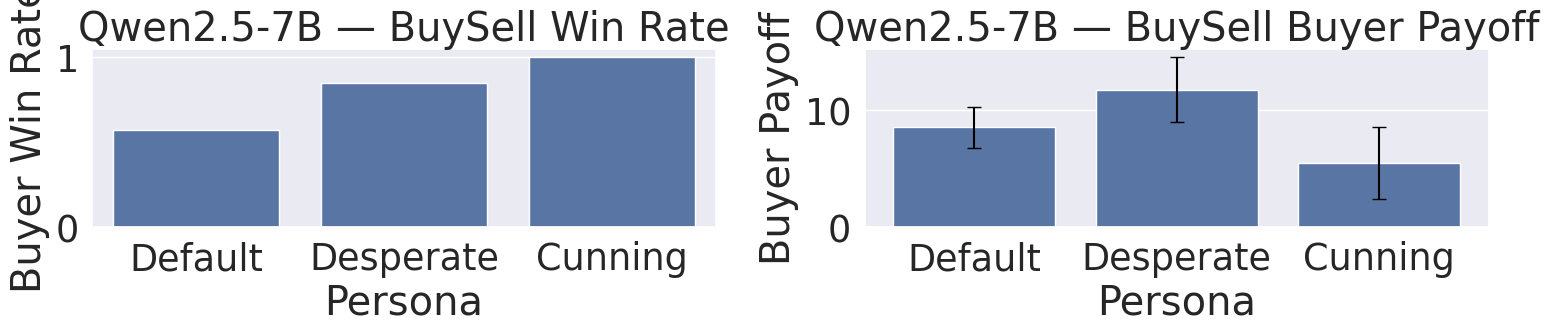

No data for Llama-3-8B, skipping.


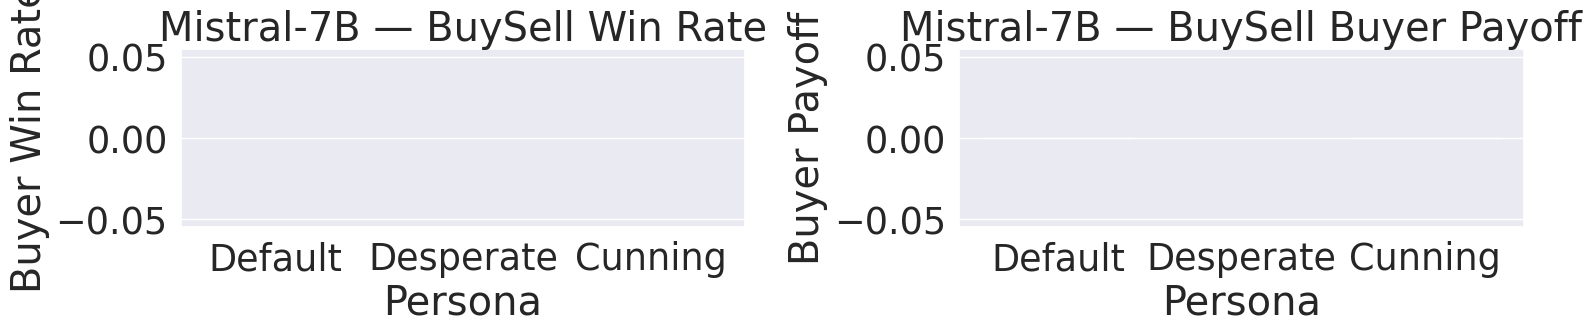

In [15]:
#  Per-model persona plots for BuySell 

for model_name in AGENTS_CLEAN_NAMES:
    sub = bs[bs["model_1"] == model_name].copy()
    if len(sub) == 0:
        print(f"No data for {model_name}, skipping.")
        continue

    agg = buysell_persona_aggregation(sub)
    agg = agg.set_index("social_2").reindex(PERSONAS)

    fig, axs = plt.subplots(figsize=(16, 4), ncols=2)
    fig.tight_layout()

    # Win Rate (buyer/P2 perspective)
    sns.barplot(data=agg.reset_index(), x="social_2", y="win_2_mean",
                order=PERSONAS, ax=axs[0])
    axs[0].set_xlabel("Persona")
    axs[0].set_ylabel("Buyer Win Rate")
    axs[0].set_title(f"{model_name} — BuySell Win Rate")

    # Buyer Payoff
    sns.barplot(data=agg.reset_index(), x="social_2", y="outcome_2_mean",
                order=PERSONAS, ax=axs[1])
    axs[1].errorbar(x=range(len(PERSONAS)),
                    y=agg["outcome_2_mean"].values,
                    yerr=agg["outcome_2_sem"].values,
                    fmt='none', c='black', capsize=5)
    axs[1].set_xlabel("Persona")
    axs[1].set_ylabel("Buyer Payoff")
    axs[1].set_title(f"{model_name} — BuySell Buyer Payoff")

    fig.tight_layout()
    fig.savefig(f"_notebooks/figures/{FIGURE_PRENAME}_buysell_{model_name}.pdf",
                bbox_inches='tight')
    plt.show()

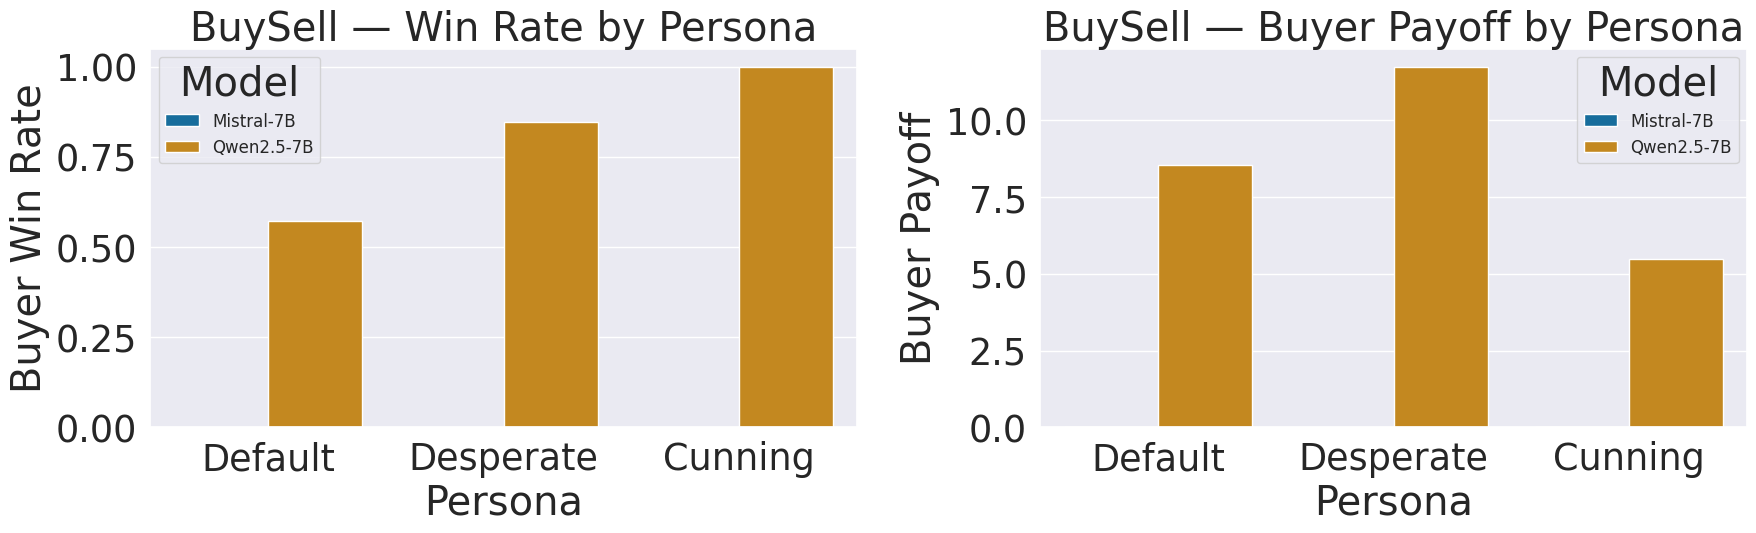

In [16]:
#  Combined BuySell plot 

agg_all = buysell_persona_aggregation(bs)

fig, axs = plt.subplots(figsize=(18, 6), ncols=2)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="win_2_mean",
            hue="model_1", order=PERSONAS, ax=axs[0], palette="colorblind")
axs[0].set_xlabel("Persona")
axs[0].set_ylabel("Buyer Win Rate")
axs[0].set_title("BuySell — Win Rate by Persona")
axs[0].legend(title="Model", fontsize=12)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="outcome_2_mean",
            hue="model_1", order=PERSONAS, ax=axs[1], palette="colorblind")
axs[1].set_xlabel("Persona")
axs[1].set_ylabel("Buyer Payoff")
axs[1].set_title("BuySell — Buyer Payoff by Persona")
axs[1].legend(title="Model", fontsize=12)

fig.tight_layout()
fig.savefig(f"_notebooks/figures/{FIGURE_PRENAME}_buysell_combined.pdf",
            bbox_inches='tight')
plt.show()

---
## Game Completion Rates by Persona

Important sanity check: do personas cause more games to break?

In [17]:
def load_completion_stats_with_persona(log_dirs):
    """Count total vs completed games, including persona info."""
    rows = []
    for game_name, log_dir in log_dirs.items():
        for root, dirs, files in os.walk(log_dir):
            if "game_state.json" not in files:
                continue
            path = os.path.join(root, "game_state.json")
            try:
                with open(path) as f:
                    data = json.load(f)
                players = data["players"]
                settings = data["game_state"][0].get("settings", {})
                behaviours = settings.get("player_social_behaviour", ["", ""])
                last = data["game_state"][-1]
                completed = last.get("current_iteration") == "END"
                rows.append({
                    "game": game_name,
                    "model_1": players[0].get("model_id", players[0].get("model", "unknown")),
                    "social_2": behaviours[1] if len(behaviours) > 1 else "",
                    "completed": completed,
                })
            except Exception:
                pass
    return pd.DataFrame(rows)


log_dirs = {
    "Trading": LOGS_ROOT_TRADING,
    "Ultimatum": LOGS_ROOT_ULTIMATUM,
    "BuySell": LOGS_ROOT_BUYSELL,
}

df_comp = load_completion_stats_with_persona(log_dirs)
df_comp["model_1"] = df_comp["model_1"].replace(rename_dict)

# Map behaviours to persona names (merge all game-specific dicts)
all_behaviour_map = {}
all_behaviour_map.update(BEHAVIOUR_TO_NAME_TRADING)
all_behaviour_map.update(BEHAVIOUR_TO_NAME_ULTIMATUM)
all_behaviour_map.update(BEHAVIOUR_TO_NAME_BUYSELL)
df_comp["persona"] = df_comp["social_2"].replace(all_behaviour_map)

comp_agg = df_comp.groupby(["game", "model_1", "persona"]).agg(
    total=("completed", "count"),
    completed=("completed", "sum"),
).reset_index()
comp_agg["pct"] = comp_agg["completed"] / comp_agg["total"] * 100

print(comp_agg.to_string(index=False))

     game    model_1   persona  total  completed        pct
  BuySell Llama-3-8B   Cunning     30          0   0.000000
  BuySell Llama-3-8B   Default     30          0   0.000000
  BuySell Llama-3-8B Desperate     30          0   0.000000
  BuySell Mistral-7B   Cunning     30          1   3.333333
  BuySell Mistral-7B   Default     30          1   3.333333
  BuySell Mistral-7B Desperate     30          0   0.000000
  BuySell Qwen2.5-7B   Cunning     30         21  70.000000
  BuySell Qwen2.5-7B   Default     30         30 100.000000
  BuySell Qwen2.5-7B Desperate     30         24  80.000000
  Trading Llama-3-8B   Cunning     30         15  50.000000
  Trading Llama-3-8B   Default     30         21  70.000000
  Trading Llama-3-8B Desperate     30         11  36.666667
  Trading Mistral-7B   Cunning     30          8  26.666667
  Trading Mistral-7B   Default     30         12  40.000000
  Trading Mistral-7B Desperate     30         10  33.333333
  Trading Qwen2.5-7B   Cunning     30   

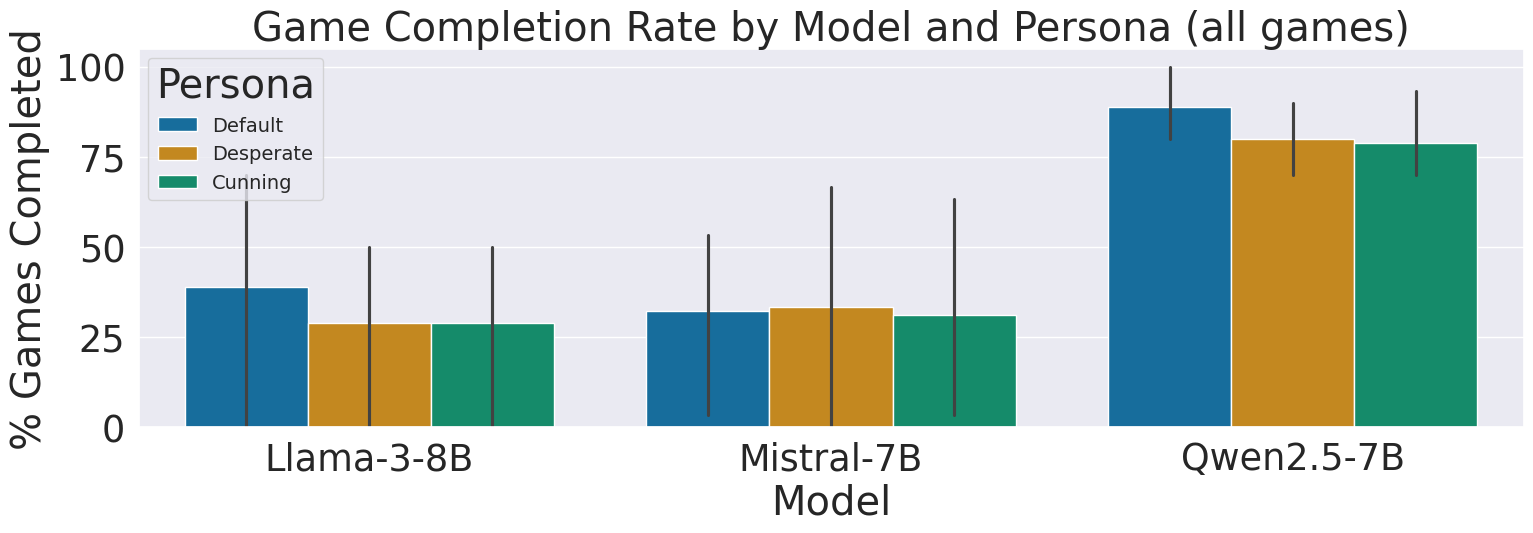

In [18]:
#  Completion rate bar plot 

fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=comp_agg, x="model_1", y="pct",
            hue="persona", hue_order=PERSONAS,
            palette="colorblind", ax=ax)
ax.set_ylabel("% Games Completed")
ax.set_xlabel("Model")
ax.set_title("Game Completion Rate by Model and Persona (all games)")
ax.set_ylim(0, 105)
ax.legend(title="Persona", fontsize=14)
fig.tight_layout()
fig.savefig(f"_notebooks/figures/{FIGURE_PRENAME}_completion_by_persona.pdf",
            bbox_inches='tight')
plt.show()